In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests
import gzip
import io
import json

In [10]:
# nomes dos arquivos de entrada e saída
ZAP_REPORT_FILE = '2025-06-29-ZAP-Report-.json'
NVD_CVE_FILE = 'nvdcve-2.0-combined_small.json'
OUTPUT_CSV_FILE = 'dataset_vulnerabilidades_simulado.csv'

def extrair_dados_cve(nvd_filepath):
    """
    Lê o arquivo JSON do NVD e extrai as informações das vulnerabilidades,
    reclassificando a severidade baseada na pontuação numérica.
    """
    print(f"Lendo o arquivo de CVEs: {nvd_filepath}...")
    try:
        with open(nvd_filepath, 'r', encoding='utf-8') as f:
            nvd_data = json.load(f)
    except FileNotFoundError:
        print(f"ERRO: Arquivo não encontrado: '{nvd_filepath}'.")
        return None

    # --- lógica de classificação corrigida conforme solicitado ---
    def classificar_severidade_por_score(score):
        """Classifica a severidade baseada na pontuação numérica."""
        if 9.0 <= score <= 10.0:
            return 'CRITICAL'
        elif 7.0 <= score <= 8.9:
            return 'HIGH'
        elif 4.0 <= score <= 6.9:
            return 'MEDIUM'
        elif 0.1 <= score <= 3.9:
            return 'LOW'
        else:
            return 'NONE' # para scores de 0.0

    cves_processadas = []
    print("Processando e reclassificando a severidade das CVEs...")
    for item in nvd_data.get('vulnerabilities', []):
        cve_info = item.get('cve', {})
        metrics = cve_info.get('metrics', {})
        cvss_v2_list = metrics.get('cvssMetricV2', [])
        if cvss_v2_list:
            base_score = cvss_v2_list[0].get('cvssData', {}).get('baseScore', 0.0)
            
            # usa a nossa função para definir a severidade, ignorando a do arquivo
            severidade_corrigida = classificar_severidade_por_score(base_score)
            
            cves_processadas.append({
                'cve': cve_info.get('id', 'N/A'),
                'cvss': base_score,
                'severidade': severidade_corrigida # usamos a severidade corrigida
            })
            
    print(f"{len(cves_processadas)} CVEs carregadas e reclassificadas com sucesso.")
    return cves_processadas

def gerar_dataset_simulado(zap_filepath, lista_cves):
    """Lê o relatório ZAP e gera as linhas do dataset com VIÉS para alta criticidade."""
    print(f"Lendo o relatório de vulnerabilidades: {zap_filepath}...")
    try:
        with open(zap_filepath, 'r', encoding='utf-8') as f:
            zap_data = json.load(f)
    except FileNotFoundError:
        print(f"ERRO: Arquivo não encontrado: '{zap_filepath}'.")
        return None
        
    # o mapa de pesos agora funcionará corretamente com a severidade reclassificada
    mapa_de_pesos = {
        'CRITICAL': 10,
        'HIGH': 8,
        'MEDIUM': 2,
        'LOW': 1,
        'NONE': 0
    }
    pesos = [mapa_de_pesos.get(cve['severidade'], 1) for cve in lista_cves]
    
    dataset_rows = []
    print("Gerando simulação com viés para vulnerabilidades críticas...")
    for site in zap_data.get('site', []):
        for alerta in site.get('alerts', []):
            for instancia in alerta.get('instances', []):
                # usa a escolha ponderada para selecionar uma cve
                cve_simulada = random.choices(lista_cves, weights=pesos, k=1)[0]
                
                linha = {
                    'nome': alerta.get('name', 'Alerta Desconhecido'),
                    'cve': cve_simulada['cve'],
                    'cvss (0-10)': cve_simulada['cvss'],
                    'cvs (qualitativo)': cve_simulada['severidade'],
                    'url da vulnerabilidade': instancia.get('uri', 'URL N/A'),
                    'site': site.get('@name', 'N/A')
                }
                dataset_rows.append(linha)
    return dataset_rows

# --- execução principal ---
print("Iniciando a geração do novo dataset simulado...")
lista_de_cves = extrair_dados_cve(NVD_CVE_FILE)
if lista_de_cves:
    dataset_final_list = gerar_dataset_simulado(ZAP_REPORT_FILE, lista_de_cves)
    if dataset_final_list:
        df = pd.DataFrame(dataset_final_list)
        df.to_csv(OUTPUT_CSV_FILE, index=False, encoding='utf-8')
        print(f"\nSUCESSO! Dataset corrigido com {len(df)} linhas foi salvo em '{os.path.abspath(OUTPUT_CSV_FILE)}'")
        print("Agora, execute a célula de análise para visualizar o novo cenário.")

Iniciando a geração do novo dataset simulado...
Lendo o arquivo de CVEs: nvdcve-2.0-combined_small.json...
Processando e reclassificando a severidade das CVEs...
18125 CVEs carregadas e reclassificadas com sucesso.
Lendo o relatório de vulnerabilidades: 2025-06-29-ZAP-Report-.json...
Gerando simulação com viés para vulnerabilidades críticas...

SUCESSO! Dataset corrigido com 45498 linhas foi salvo em 'd:\OneDrive - SEBRAE\Documentos\vscodescripts\unb projeto\dataset_vulnerabilidades_simulado.csv'
Agora, execute a célula de análise para visualizar o novo cenário.


Carregando o dataset original: dataset_vulnerabilidades_simulado.csv
Dataset original carregado com 45498 linhas.

--- Distribuição Original ---
site
https://dspace.mj.gov.br              28699
https://eadsegen.mj.gov.br             8298
https://eadespen.mj.gov.br             3597
https://desarma.mj.gov.br              1243
https://biblivre.mj.gov.br              692
https://drive.diop.mj.gov.br            551
https://drive.cronos.mj.gov.br          503
https://ciber.mj.gov.br                 486
https://intranet.dfnsp.mj.gov.br        464
https://atendimento.ciof.mj.gov.br      220
https://consultasei.mj.gov.br           146
https://cidadao.dev.mj.gov.br           140
https://agente.dev.mj.gov.br            140
https://seg.dev.mj.gov.br               114
https://competencias.mj.gov.br           45
https://alterasenha.mj.gov.br            16
http://ciber.mj.gov.br                   15
http://alterasenha.mj.gov.br             12
http://eadespen.mj.gov.br                11
http://intrane

C:\Users\madso\AppData\Local\Temp\ipykernel_18840\1826417454.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nova_distribuicao.index, y=nova_distribuicao.values, palette='viridis')


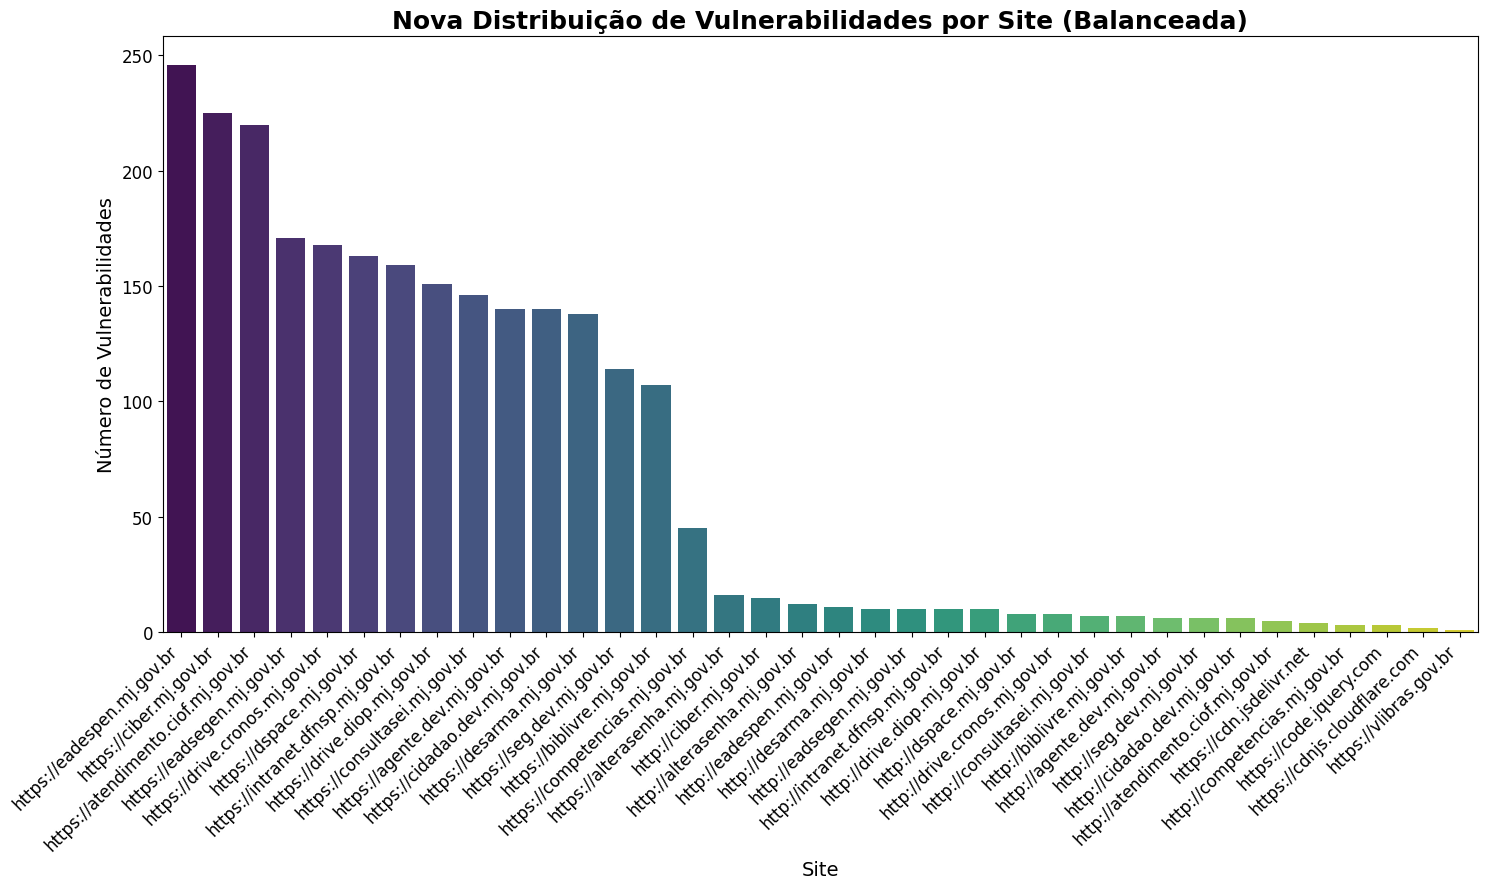

In [2]:
# --- parâmetros ---
ARQUIVO_ENTRADA = 'dataset_vulnerabilidades_simulado.csv'
ARQUIVO_SAIDA = 'dataset_vulnerabilidades_balanceado_final.csv'

# --- lógica de balanceamento variável ---
# para sites com muitas vulnerabilidades, sortearemos um número entre estes valores.
MIN_VULNS_POR_SITE = 50 
MAX_VULNS_POR_SITE = 250 

# --- execução do script ---

print(f"Carregando o dataset original: {ARQUIVO_ENTRADA}")
if not os.path.exists(ARQUIVO_ENTRADA):
    print(f"ERRO: Arquivo '{ARQUIVO_ENTRADA}' não foi encontrado.")
else:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print(f"Dataset original carregado com {len(df)} linhas.")

    print("\n--- Distribuição Original ---")
    print(df['site'].value_counts())

    # --- lógica de balanceamento variável aplicada ---
    print(f"\n--- Aplicando balanceamento com limite variável entre {MIN_VULNS_POR_SITE} e {MAX_VULNS_POR_SITE} ---")
    
    # agrupa o dataframe por site
    grouped = df.groupby('site')
    df_balanceado_lista = []

    for site_nome, grupo in grouped:
        if len(grupo) > MAX_VULNS_POR_SITE:
            # se o grupo é maior que o teto, sorteia um limite aleatório
            limite_aleatorio = random.randint(MIN_VULNS_POR_SITE, MAX_VULNS_POR_SITE)
            # pega uma amostra aleatória com o novo limite
            df_balanceado_lista.append(grupo.sample(n=limite_aleatorio, random_state=42))
        else:
            # se o grupo é menor, mantém todos os dados
            df_balanceado_lista.append(grupo)
            
    # concatena a lista de dataframes de volta em um único dataframe
    df_balanceado = pd.concat(df_balanceado_lista).reset_index(drop=True)

    print("\n--- Distribuição Nova e Balanceada ---")
    nova_distribuicao = df_balanceado['site'].value_counts()
    print(nova_distribuicao)
    
    # --- salvando o novo dataset ---
    df_balanceado.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8')
    print(f"\nSUCESSO! Novo dataset balanceado com {len(df_balanceado)} linhas foi salvo como '{ARQUIVO_SAIDA}'")

    # --- gerando gráfico de verificação ---
    print("\n--- Gerando gráfico com a nova distribuição para verificação ---")
    plt.figure(figsize=(15, 9))
    ax = sns.barplot(x=nova_distribuicao.index, y=nova_distribuicao.values, palette='viridis')
    ax.set_title(f'Nova Distribuição de Vulnerabilidades por Site (Balanceada)', fontsize=18, weight='bold')
    ax.set_xlabel('Site', fontsize=14)
    ax.set_ylabel('Número de Vulnerabilidades', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

In [1]:
# --- parâmetros ---
ARQUIVO_ENTRADA = 'dataset_vulnerabilidades_balanceado_final.csv'
ARQUIVO_SAIDA = 'dataset_enriquecido_epss.csv'

# --- função para baixar e processar dados do epss ---

def baixar_e_carregar_epss():
    """
    Baixa os dados mais recentes do EPSS, descompacta em memória e carrega em um DataFrame.
    """
    # url oficial para o arquivo csv compactado do epss
    url = "https://epss.cyentia.com/epss_scores-current.csv.gz"
    print(f"Baixando dados do EPSS diretamente de: {url}...")
    
    try:
        response = requests.get(url, stream=True)
        # verifica se o download foi bem-sucedido
        response.raise_for_status()
        
        # o arquivo é .gz, então precisamos descompactá-lo em memória
        with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as gz_file:
            # o arquivo do epss tem uma linha de cabeçalho de comentário que precisa ser ignorada
            # lemos a primeira linha para checar
            header = gz_file.readline().decode('utf-8').strip()
            
            # se a linha começar com '#', lemos o resto do arquivo normalmente
            if header.startswith("#"):
                 df_epss = pd.read_csv(gz_file)
            else:
                # caso contrário (se o formato mudar), voltamos ao início e lemos tudo
                gz_file.seek(0)
                df_epss = pd.read_csv(gz_file)

        print(f"Dados do EPSS carregados com sucesso. Total de {len(df_epss)} CVEs encontradas.")
        return df_epss
        
    except requests.exceptions.RequestException as e:
        print(f"ERRO: Falha ao baixar o arquivo do EPSS. Verifique sua conexão com a internet. Detalhes: {e}")
        return None

# --- execução principal ---

print(f"Carregando o seu dataset balanceado: {ARQUIVO_ENTRADA}")
if not os.path.exists(ARQUIVO_ENTRADA):
    print(f"ERRO: Arquivo '{ARQUIVO_ENTRADA}' não encontrado.")
else:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print(f"Dataset original carregado com {len(df)} linhas.")

    # 1. baixar os dados do epss
    df_epss = baixar_e_carregar_epss()

    if df_epss is not None:
        # 2. juntar (merge) os datasets
        print("\n--- Enriquecendo o dataset com as pontuações EPSS ---")
        
        # usamos 'left' merge para manter todas as vulnerabilidades do nosso dataset,
        # mesmo que alguma não seja encontrada no arquivo do epss.
        df_enriquecido = pd.merge(df, df_epss, on='cve', how='left')
        
        # 3. tratamento de dados pós-merge
        # vulnerabilidades sem score epss receberão o valor 0.
        # a coluna 'percentile' do epss não é necessária para nossa análise, então executa removê-la.
        df_enriquecido['epss'] = df_enriquecido['epss'].fillna(0)
        if 'percentile' in df_enriquecido.columns:
            df_enriquecido = df_enriquecido.drop(columns=['percentile'])
        
        print("Merge concluído. Vulnerabilidades sem score EPSS receberam o valor 0.")
        
        # 4. salvando o novo dataset enriquecido
        df_enriquecido.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8')
        print(f"\nSUCESSO! Novo dataset enriquecido foi salvo como '{ARQUIVO_SAIDA}'")

        # 5. verificação final
        print("\n--- Amostra do Dataset Enriquecido (com a nova coluna 'epss') ---")
        display(df_enriquecido.head())

Carregando o seu dataset balanceado: dataset_vulnerabilidades_balanceado_final.csv
Dataset original carregado com 2493 linhas.
Baixando dados do EPSS diretamente de: https://epss.cyentia.com/epss_scores-current.csv.gz...
Dados do EPSS carregados com sucesso. Total de 286241 CVEs encontradas.

--- Enriquecendo o dataset com as pontuações EPSS ---
Merge concluído. Vulnerabilidades sem score EPSS receberam o valor 0.

SUCESSO! Novo dataset enriquecido foi salvo como 'dataset_enriquecido_epss.csv'

--- Amostra do Dataset Enriquecido (com a nova coluna 'epss') ---


,nome,cve,cvss (0-10),cvs (qualitativo),url da vulnerabilidade,site,epss
0,Content Security Policy (CSP) Header Not Set,CVE-2024-7897,6.5,MEDIUM,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,0.00576
1,Missing Anti-clickjacking Header,CVE-2000-0936,2.1,LOW,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,0.00357
2,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2695,7.5,HIGH,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,0.00738
3,"Server Leaks Version Information via ""Server"" ...",CVE-1999-0667,10.0,CRITICAL,http://agente.dev.mj.gov.br/robots.txt,http://agente.dev.mj.gov.br,0.44366
4,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2071,7.5,HIGH,http://agente.dev.mj.gov.br/sitemap.xml,http://agente.dev.mj.gov.br,0.04938


In [1]:
# --- parâmetros ---
ARQUIVO_SITES = 'sites_distintos.csv'
ARQUIVO_VULNS = 'dataset_vulnerabilidades_balanceado_final.csv'
ARQUIVO_SAIDA_RELATORIO = 'relatorio_final_criticidade_ponderado.csv'

# --- execução principal ---

print("--- Etapa 1: Contando vulnerabilidades por site ---")
try:
    df_sites_unicos = pd.read_csv(ARQUIVO_SITES)
    df_vulns = pd.read_csv(ARQUIVO_VULNS)
    print("Arquivos de sites e vulnerabilidades carregados.")
except FileNotFoundError as e:
    print(f"ERRO: Arquivo não encontrado. Detalhes: {e}")
else:
    # contagem de vulnerabilidades
    contagem_vulns = df_vulns['site'].value_counts().reset_index()
    contagem_vulns.columns = ['site', 'contagem_vulns']
    
    # juntando com a lista de sites para garantir que todos os 36 estão presentes
    df_sites = pd.merge(df_sites_unicos, contagem_vulns, on='site', how='left').fillna(0)
    df_sites_ordenado = df_sites.sort_values(by='contagem_vulns', ascending=False).reset_index(drop=True)

    # --- etapa 2: dividindo os sites em terços ---
    print("--- Etapa 2: Dividindo os sites em 3 terços com base na contagem de vulnerabilidades ---")
    terco = len(df_sites_ordenado) // 3
    sites_terco_superior = df_sites_ordenado.iloc[:terco]
    sites_terco_intermediario = df_sites_ordenado.iloc[terco:2*terco]
    sites_terco_inferior = df_sites_ordenado.iloc[2*terco:]

    # --- etapa 3: definindo os perfis de resposta ---
    respostas_impacto = ['Sim', 'Não']
    respostas_vuln = ['Não', 'Sim, menos da metade do sistema/módulo', 'Sim, mais da metade do sistema/módulo', 'Sim, totalmente']
    
    # --- etapa 4: gerando a avaliação simulada com a lógica de ponderação ---
    print("--- Etapa 3: Gerando a avaliação com base nos perfis e na regra 70/30 ---")
    lista_avaliacoes = []
    
    # função para gerar respostas com base no perfil
    def gerar_respostas(perfil):
        respostas = {}
        # perfil "sistema importante": alto impacto, baixa vulnerabilidade (bons controles)
        if perfil == 'Importante':
            for i in range(1, 13): respostas[f'q{i}'] = np.random.choice(respostas_impacto, p=[0.8, 0.2]) # 80% de chance de ser 'sim'
            for i in range(13, 23): respostas[f'q{i}'] = np.random.choice(respostas_vuln, p=[0.1, 0.1, 0.1, 0.7]) # 70% de chance de ser 'sim, totalmente'
        # perfil "sistema negligenciado": baixo impacto, alta vulnerabilidade (maus controles)
        elif perfil == 'Negligenciado':
            for i in range(1, 13): respostas[f'q{i}'] = np.random.choice(respostas_impacto, p=[0.2, 0.8]) # 80% de chance de ser 'não'
            for i in range(13, 23): respostas[f'q{i}'] = np.random.choice(respostas_vuln, p=[0.7, 0.1, 0.1, 0.1]) # 70% de chance de ser 'não'
        # perfil "aleatório"
        else:
            for i in range(1, 13): respostas[f'q{i}'] = random.choice(respostas_impacto)
            for i in range(13, 23): respostas[f'q{i}'] = random.choice(respostas_vuln)
        return respostas

    # aplicando a regra 70/30
    for i, row in df_sites_ordenado.iterrows():
        sistema = row['site']
        perfil_definido = 'Aleatório' # padrão
        
        # terço superior
        if i < terco:
            perfil_definido = 'Negligenciado' if i < terco * 0.7 else 'Aleatório'
        # terço inferior
        elif i >= 2 * terco:
            perfil_definido = 'Importante' if i < (2 * terco) + (terco * 0.7) else 'Aleatório'
            
        respostas_sistema = gerar_respostas(perfil_definido)
        respostas_sistema['sistema'] = sistema
        respostas_sistema['perfil_simulado'] = perfil_definido
        lista_avaliacoes.append(respostas_sistema)

    df_avaliacoes = pd.DataFrame(lista_avaliacoes)
    
    # --- etapa 5: aplicando o cálculo de criticidade ---
    print("--- Etapa 4: Calculando as notas e a classificação final ---")
    
    # reutilizando a lógica de cálculo já validada
    mapa_valores_impacto = {'Sim': 1, 'Não': 0}
    pesos_impacto = {f'I.{i+1}': p/100 for i, p in enumerate([20.0, 15.0, 6.0, 6.0, 2.5, 6.0, 2.5, 6.0, 10.0, 6.0, 10.0, 10.0])}
    mapa_valores_vuln_direta = {'Não': 0, 'Sim, menos da metade do sistema/módulo': 0.33, 'Sim, mais da metade do sistema/módulo': 0.66, 'Sim, totalmente': 1}
    mapa_valores_vuln_inversa = {'Não': 1, 'Sim, menos da metade do sistema/módulo': 0.66, 'Sim, mais da metade do sistema/módulo': 0.33, 'Sim, totalmente': 0}
    pesos_vulnerabilidade = {f'V.{i+13}': p/100 for i, p in enumerate([10.0, 8.0, 20.0, 5.0, 10.0, 8.0, 10.0, 8.0, 16.0, 5.0])}
    questoes_diretas_vuln = ['q16', 'q20']
    
    def calcular_nota_impacto(row):
        score = 0
        for i in range(1, 13): score += mapa_valores_impacto.get(row[f'q{i}'], 0) * pesos_impacto[f'I.{i}']
        return score

    def calcular_nota_vulnerabilidade(row):
        score = 0
        for i in range(13, 23):
            mapa_usado = mapa_valores_vuln_direta if f'q{i}' in questoes_diretas_vuln else mapa_valores_vuln_inversa
            score += mapa_usado.get(row[f'q{i}'], 0) * pesos_vulnerabilidade[f'V.{i}']
        return score
    
    df_avaliacoes['nota impacto'] = df_avaliacoes.apply(calcular_nota_impacto, axis=1)
    df_avaliacoes['notavulnerabilidade'] = df_avaliacoes.apply(calcular_nota_vulnerabilidade, axis=1)
    df_avaliacoes['notacriticidade'] = (2 * df_avaliacoes['nota impacto']) + df_avaliacoes['notavulnerabilidade']
    
    def classificar_criticidade(row):
        if row['nota impacto'] > 0.7 or row['notacriticidade'] >= 1.4: return 'Alta'
        elif row['nota impacto'] >= 0.5 or row['notacriticidade'] >= 1.0: return 'Média'
        else: return 'Baixa'
            
    df_avaliacoes['nivel de criticidade'] = df_avaliacoes.apply(classificar_criticidade, axis=1)
    
    mapa_grupo_impl = {'Alta': 'Grupo 1 (Ação Imediata)', 'Média': 'Grupo 2 (Planejar Correção)', 'Baixa': 'Grupo 3 (Monitorar)'}
    df_avaliacoes['grupodeimplementação'] = df_avaliacoes['nivel de criticidade'].map(mapa_grupo_impl)

    # --- etapa 6: gerando o csv final ---
    print("--- Etapa 5: Gerando o CSV final ---")
    
    ordem_colunas_final = ['sistema'] + [f'q{i}' for i in range(1, 23)] + ['nota impacto', 'notavulnerabilidade', 'notacriticidade', 'nivel de criticidade', 'grupodeimplementação', 'perfil_simulado']
    df_final = df_avaliacoes[ordem_colunas_final]
    
    df_final.to_csv(ARQUIVO_SAIDA_RELATORIO, index=False, encoding='utf-8', sep=';')
    print(f"\nSUCESSO! Relatório final com dados ponderados foi salvo como '{ARQUIVO_SAIDA_RELATORIO}'")
    
    print("\n--- Amostra do Relatório Final Ponderado ---")
    display(df_final.head())
    
    print("\n--- Verificação da Distribuição dos Perfis Simulados ---")
    display(df_final['perfil_simulado'].value_counts())

--- Etapa 1: Contando vulnerabilidades por site ---
Arquivos de sites e vulnerabilidades carregados.
--- Etapa 2: Dividindo os sites em 3 terços com base na contagem de vulnerabilidades ---
--- Etapa 3: Gerando a avaliação com base nos perfis e na regra 70/30 ---
--- Etapa 4: Calculando as notas e a classificação final ---
--- Etapa 5: Gerando o CSV final ---

SUCESSO! Relatório final com dados ponderados foi salvo como 'relatorio_final_criticidade_ponderado.csv'

--- Amostra do Relatório Final Ponderado ---


,sistema,q1,q2,q3,q4,q5,q6,q7,q8,q9,...,q19,q20,q21,q22,nota impacto,notavulnerabilidade,notacriticidade,nivel de criticidade,grupodeimplementação,perfil_simulado
0,https://eadespen.mj.gov.br,Não,Não,Sim,Não,Não,Sim,Sim,Não,Sim,...,Não,Não,Não,"Sim, menos da metade do sistema/módulo",0.245,0.7258,1.2158,Média,Grupo 2 (Planejar Correção),Negligenciado
1,https://ciber.mj.gov.br,Não,Não,Não,Não,Sim,Não,Não,Não,Não,...,Não,Não,"Sim, menos da metade do sistema/módulo",Não,0.125,0.7884,1.0384,Média,Grupo 2 (Planejar Correção),Negligenciado
2,https://atendimento.ciof.mj.gov.br,Não,Sim,Sim,Não,Sim,Não,Não,Sim,Não,...,Não,Não,Não,Não,0.295,0.7900,1.3800,Média,Grupo 2 (Planejar Correção),Negligenciado
3,https://eadsegen.mj.gov.br,Não,Não,Não,Não,Sim,Não,Sim,Não,Não,...,Não,Não,Não,Não,0.110,0.7700,0.9900,Baixa,Grupo 3 (Monitorar),Negligenciado
4,https://drive.cronos.mj.gov.br,Não,Não,Não,Não,Não,Não,Não,Não,Não,...,Não,Não,Não,Não,0.100,0.5854,0.7854,Baixa,Grupo 3 (Monitorar),Negligenciado



--- Verificação da Distribuição dos Perfis Simulados ---


perfil_simulado
Aleatório        18
Negligenciado     9
Importante        9
Name: count, dtype: int64

In [1]:
# --- parâmetros ---
# arquivo de entrada principal (com as vulnerabilidades e epss)
ARQUIVO_VULNS = 'dataset_enriquecido_epss.csv'
# arquivo com a nota de criticidade calculada para cada sistema
ARQUIVO_CRITICIDADE = 'relatorio_final_criticidade_ponderado.csv'
# nome do arquivo de saída final
ARQUIVO_SAIDA = 'dataset_vulns_epss_ppsi.csv'

# --- execução do script ---

print("--- Etapa 1: Carregando os datasets ---")
try:
    df_vulns = pd.read_csv(ARQUIVO_VULNS)
    # lembrar que o relatório usa ';' como separador
    df_criticidade = pd.read_csv(ARQUIVO_CRITICIDADE, sep=';')
    print("Datasets de vulnerabilidades e de criticidade dos sistemas carregados com sucesso.")
except FileNotFoundError as e:
    print(f"ERRO: Arquivo não encontrado. Verifique se os nomes dos arquivos estão corretos. Detalhes: {e}")
else:
    # --- etapa 2: preparando os dados para o merge ---
    print("\n--- Etapa 2: Preparando para unir os dados ---")
    
    # do relatório de criticidade, precisamos apenas do nome do sistema e da nota final
    df_scores = df_criticidade[['sistema', 'notacriticidade']].copy()
    
    # para unir os dois dataframes, a coluna chave precisa ter o mesmo nome.
    # executa renomear 'sistema' para 'site' para corresponder ao dataframe de vulnerabilidades.
    df_scores.rename(columns={'sistema': 'site'}, inplace=True)
    
    print("Dados de criticidade prontos para serem adicionados.")

    # --- etapa 3: unindo os datasets ---
    print("Adicionando a 'notacriticidade' ao dataset principal de vulnerabilidades...")
    
    # usamos 'left' merge para garantir que todas as vulnerabilidades do dataset original sejam mantidas
    df_final = pd.merge(df_vulns, df_scores, on='site', how='left')
    
    # lidando com possíveis sites que não foram avaliados: preenchemos a nota com a mediana
    mediana_criticidade = df_final['notacriticidade'].median()
    df_final['notacriticidade'].fillna(mediana_criticidade, inplace=True)
    
    print("Enriquecimento concluído.")

    # --- etapa 4: salvando o dataset final ---
    df_final.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8')
    print(f"\nSUCESSO! Dataset final enriquecido com a nota de criticidade foi salvo como '{ARQUIVO_SAIDA}'")

    # --- etapa 5: verificação ---
    print("\n--- Amostra do Dataset Final ---")
    # exibe as colunas relevantes para verificar o resultado
    colunas_display = ['cve', 'site', 'cvss (0-10)', 'epss', 'notacriticidade']
    display(df_final[colunas_display].head())
    
    print("\n--- Informações do Dataset Final ---")
    df_final.info()

--- Etapa 1: Carregando os datasets ---
Datasets de vulnerabilidades e de criticidade dos sistemas carregados com sucesso.

--- Etapa 2: Preparando para unir os dados ---
Dados de criticidade prontos para serem adicionados.
Adicionando a 'notacriticidade' ao dataset principal de vulnerabilidades...
Enriquecimento concluído.

SUCESSO! Dataset final enriquecido com a nota de criticidade foi salvo como 'dataset_vulns_epss_ppsi.csv'

--- Amostra do Dataset Final ---


C:\Users\madso\AppData\Local\Temp\ipykernel_11428\429570169.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['notacriticidade'].fillna(mediana_criticidade, inplace=True)


,cve,site,cvss (0-10),epss,notacriticidade
0,CVE-2024-7897,http://agente.dev.mj.gov.br,6.5,0.00576,1.9452
1,CVE-2000-0936,http://agente.dev.mj.gov.br,2.1,0.00357,1.9452
2,CVE-2004-2695,http://agente.dev.mj.gov.br,7.5,0.00738,1.9452
3,CVE-1999-0667,http://agente.dev.mj.gov.br,10.0,0.44366,1.9452
4,CVE-2004-2071,http://agente.dev.mj.gov.br,7.5,0.04938,1.9452



--- Informações do Dataset Final ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2493 entries, 0 to 2492
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nome                    2493 non-null   object 
 1   cve                     2493 non-null   object 
 2   cvss (0-10)             2493 non-null   float64
 3   cvs (qualitativo)       2493 non-null   object 
 4   url da vulnerabilidade  2493 non-null   object 
 5   site                    2493 non-null   object 
 6   epss                    2493 non-null   float64
 7   notacriticidade         2493 non-null   float64
dtypes: float64(3), object(5)
memory usage: 155.9+ KB


In [2]:
import pandas as pd
import os

# --- parâmetros ---
# arquivo de entrada que contém todos os dados necessários
ARQUIVO_ENTRADA = 'dataset_vulns_epss_ppsi.csv'
# nome do arquivo de saída final e formatado
ARQUIVO_SAIDA = 'planilha_final_para_analise.csv'

# --- execução do script ---

print(f"Carregando o dataset completo: {ARQUIVO_ENTRADA}")
try:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print("Dataset carregado com sucesso.")
except FileNotFoundError as e:
    print(f"ERRO: Arquivo '{ARQUIVO_ENTRADA}' não foi encontrado. Execute o script anterior para gerá-lo.")
else:
    # --- etapa 1: definindo o mapeamento de colunas ---
    # mapeia os nomes de colunas existentes para os novos nomes desejados
    mapa_renomeacao = {
        'site': 'site',
        'url da vulnerabilidade': 'url',
        'nome': 'nome',
        'cve': 'cve',
        'cvss (0-10)': 'cvss(numerico)',
        'cvs (qualitativo)': 'cvss(qualitativo)',
        'epss': 'epss',
        'notacriticidade': 'ppsi' # renomeando a nota de criticidade para ppsi
    }
    
    # lista de colunas originais que executa precisar
    colunas_originais = list(mapa_renomeacao.keys())

    # --- etapa 2: selecionando e renomeando as colunas ---
    print("\n--- Selecionando e renomeando as colunas para o formato final ---")
    
    # verifica se todas as colunas necessárias existem no dataframe
    colunas_faltando = [col for col in colunas_originais if col not in df.columns]
    if colunas_faltando:
        print(f"ERRO: As seguintes colunas não foram encontradas no arquivo de entrada: {colunas_faltando}")
    else:
        # cria um novo dataframe apenas com as colunas que queremos
        df_intermediario = df[colunas_originais].copy()
        
        # renomeia as colunas para o nome final
        df_formatado = df_intermediario.rename(columns=mapa_renomeacao)

        # --- etapa 3: ordenando as colunas ---
        # define a ordem final exata das colunas
        ordem_final = [
            'site',
            'url',
            'nome',
            'cve',
            'cvss(numerico)',
            'cvss(qualitativo)',
            'epss',
            'ppsi'
        ]
        
        df_final = df_formatado[ordem_final]
        
        # --- etapa 4: salvando a planilha final ---
        df_final.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8', sep=';')
        print(f"\nSUCESSO! A planilha final foi gerada e salva como '{ARQUIVO_SAIDA}'")

        # --- etapa 5: verificação ---
        print("\n--- Amostra da Planilha Final Gerada ---")
        display(df_final.head())

Carregando o dataset completo: dataset_vulns_epss_ppsi.csv
Dataset carregado com sucesso.

--- Selecionando e renomeando as colunas para o formato final ---

SUCESSO! A planilha final foi gerada e salva como 'planilha_final_para_analise.csv'

--- Amostra da Planilha Final Gerada ---


,site,url,nome,cve,cvss(numerico),cvss(qualitativo),epss,ppsi
0,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,Content Security Policy (CSP) Header Not Set,CVE-2024-7897,6.5,MEDIUM,0.00576,1.9452
1,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,Missing Anti-clickjacking Header,CVE-2000-0936,2.1,LOW,0.00357,1.9452
2,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2695,7.5,HIGH,0.00738,1.9452
3,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br/robots.txt,"Server Leaks Version Information via ""Server"" ...",CVE-1999-0667,10.0,CRITICAL,0.44366,1.9452
4,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br/sitemap.xml,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2071,7.5,HIGH,0.04938,1.9452


In [1]:
# --- parâmetros ---
ARQUIVO_ENTRADA = 'planilha_final_para_analise.csv'
ARQUIVO_SAIDA = 'dataset_vuln_epss_ppsi_normalizado.csv'
# --- execução do script ---

print(f"Carregando o dataset para normalização: {ARQUIVO_ENTRADA}")
try:
    # o separador do arquivo anterior foi definido como ';'
    df = pd.read_csv(ARQUIVO_ENTRADA, sep=';')
    print("Dataset carregado com sucesso.")
except FileNotFoundError as e:
    print(f"ERRO: Arquivo '{ARQUIVO_ENTRADA}' não foi encontrado. Execute o script anterior para gerá-lo.")
else:
    # --- etapa 1: verificando os dados originais ---
    print("\n--- Estatísticas da coluna 'ppsi' (Antes da Normalização) ---")
    display(df['ppsi'].describe())
    
    # --- etapa 2: aplicando a normalização min-max ---
    print("\n--- Normalizando a coluna 'ppsi' para uma escala de 0 a 1 ---")
    
    # encontra o valor mínimo e máximo da coluna
    min_ppsi = df['ppsi'].min()
    max_ppsi = df['ppsi'].max()
    
    # aplica a fórmula de normalização min-max: (valor - mínimo) / (máximo - mínimo)
    # adicionamos uma verificação para evitar divisão por zero se todos os valores forem iguais
    if (max_ppsi - min_ppsi) > 0:
        df['ppsi_normalizado'] = (df['ppsi'] - min_ppsi) / (max_ppsi - min_ppsi)
        print("Coluna 'ppsi_normalizado' criada com sucesso.")
    else:
        # se todos os valores forem iguais, a normalização resultará em 0 para todos
        df['ppsi_normalizado'] = 0
        print("Todos os valores de 'ppsi' são idênticos. A coluna normalizada conterá apenas 0.")

    # --- etapa 3: verificando os dados normalizados ---
    print("\n--- Estatísticas da coluna 'ppsi_normalizado' (Depois da Normalização) ---")
    display(df[['ppsi', 'ppsi_normalizado']].describe())
    
    # --- etapa 4: salvando a nova planilha ---
    # executa reordenar as colunas para colocar a nova ao lado da original
    colunas_existentes = list(df.columns)
    colunas_existentes.remove('ppsi_normalizado')
    indice_ppsi = colunas_existentes.index('ppsi')
    nova_ordem = colunas_existentes[:indice_ppsi+1] + ['ppsi_normalizado'] + colunas_existentes[indice_ppsi+1:]
    
    df_final = df[nova_ordem]
    
    # salvando com separador padrão (vírgula) para compatibilidade
    df_final.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8')
    print(f"\nSUCESSO! A nova planilha com a coluna normalizada foi salva como '{ARQUIVO_SAIDA}'")

    # --- etapa 5: verificação final ---
    print("\n--- Amostra da Planilha Final com a Nova Coluna ---")
    display(df_final.head())

Carregando o dataset para normalização: planilha_final_para_analise.csv
Dataset carregado com sucesso.

--- Estatísticas da coluna 'ppsi' (Antes da Normalização) ---


count    2493.000000
mean        1.207712
std         0.378706
min         0.781600
25%         0.889000
50%         1.215800
75%         1.393000
max         2.274800
Name: ppsi, dtype: float64


--- Normalizando a coluna 'ppsi' para uma escala de 0 a 1 ---
Coluna 'ppsi_normalizado' criada com sucesso.

--- Estatísticas da coluna 'ppsi_normalizado' (Depois da Normalização) ---


,ppsi,ppsi_normalizado
count,2493.000000,2493.000000
mean,1.207712,0.285369
std,0.378706,0.253621
min,0.781600,0.000000
25%,0.889000,0.071926
50%,1.215800,0.290785
75%,1.393000,0.409456
max,2.274800,1.000000



SUCESSO! A nova planilha com a coluna normalizada foi salva como 'dataset_vuln_epss_ppsi_normalizado.csv'

--- Amostra da Planilha Final com a Nova Coluna ---


,site,url,nome,cve,cvss(numerico),cvss(qualitativo),epss,ppsi,ppsi_normalizado
0,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,Content Security Policy (CSP) Header Not Set,CVE-2024-7897,6.5,MEDIUM,0.00576,1.9452,0.779266
1,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,Missing Anti-clickjacking Header,CVE-2000-0936,2.1,LOW,0.00357,1.9452,0.779266
2,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2695,7.5,HIGH,0.00738,1.9452,0.779266
3,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br/robots.txt,"Server Leaks Version Information via ""Server"" ...",CVE-1999-0667,10.0,CRITICAL,0.44366,1.9452,0.779266
4,http://agente.dev.mj.gov.br,http://agente.dev.mj.gov.br/sitemap.xml,"Server Leaks Version Information via ""Server"" ...",CVE-2004-2071,7.5,HIGH,0.04938,1.9452,0.779266


Carregando o dataset final: dataset_vuln_epss_ppsi_normalizado.csv
Dataset carregado com 2493 linhas e 9 colunas.

--- 1.1. Amostra dos Dados (Verificando a nova coluna) ---


,site,cve,ppsi,ppsi_normalizado
0,http://agente.dev.mj.gov.br,CVE-2024-7897,1.9452,0.779266
1,http://agente.dev.mj.gov.br,CVE-2000-0936,1.9452,0.779266
2,http://agente.dev.mj.gov.br,CVE-2004-2695,1.9452,0.779266
3,http://agente.dev.mj.gov.br,CVE-1999-0667,1.9452,0.779266
4,http://agente.dev.mj.gov.br,CVE-2004-2071,1.9452,0.779266



--- 1.2. Estatísticas Descritivas das Métricas Finais de Risco ---


,count,mean,std,min,25%,50%,75%,max
epss,2493.0,0.048695,0.131745,0.0001,0.000760,0.004900,0.030470,0.94181
ppsi_normalizado,2493.0,0.285369,0.253621,0.0000,0.071926,0.290785,0.409456,1.00000


Insight: Note como agora 'epss' e 'ppsi_normalizado' possuem a mesma escala (min 0.0, max 1.0), tornando-as diretamente comparáveis.


--- 2.1. Comparando a Distribuição do PPSI Original vs. Normalizado ---


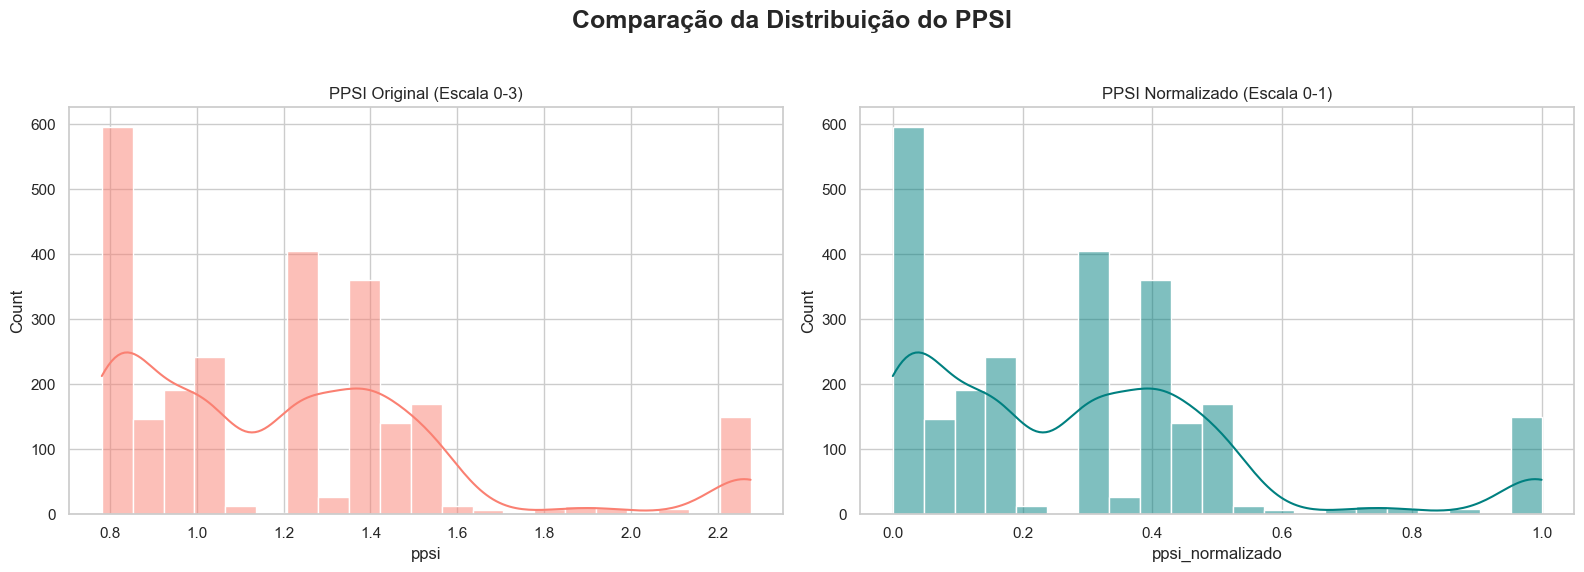

Insight: A forma da distribuição permanece a mesma, mas a escala do eixo X no gráfico da direita agora está padronizada entre 0 e 1.


--- 3.1. Correlação entre EPSS e PPSI Normalizado ---


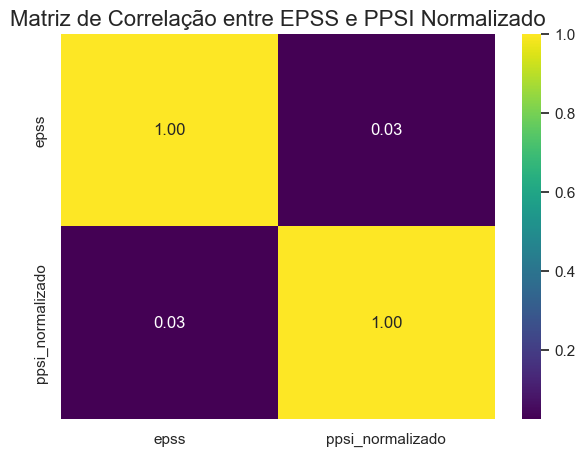

Insight: Uma correlação baixa aqui é um ótimo sinal. Significa que as duas métricas estão medindo aspectos diferentes e independentes do risco, tornando a combinação delas muito mais valiosa.

--- 3.2. Matriz de Risco Final: Probabilidade (EPSS) vs. Impacto (PPSI) ---


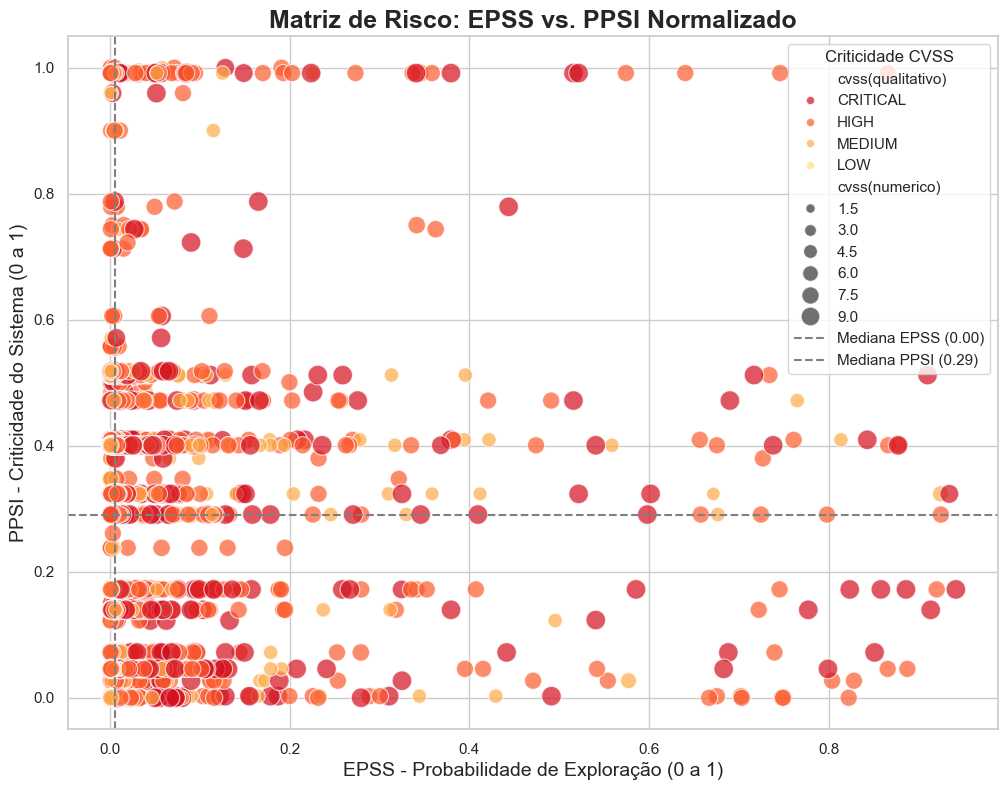


### Interpretação da Matriz de Risco:
Este gráfico é a visualização central da sua tese. Ele permite identificar perfis de risco que o CVSS sozinho não mostra:
  - **Canto Superior Direito (ALERTA MÁXIMO):** Vulnerabilidades com alta probabilidade de exploração em sistemas de altíssimo impacto para o negócio. Estas são suas prioridades absolutas, independentemente do CVSS.
  - **Canto Inferior Direito (Ameaças Comuns):** Vulnerabilidades muito exploradas, mas em sistemas de baixo impacto. Requerem atenção, mas não são emergenciais.
  - **Canto Superior Esquerdo (Gigantes Adormecidos):** Vulnerabilidades pouco exploradas, mas que residem nos seus sistemas mais críticos. Exigem monitoramento constante e planejamento para correção.
  - **Canto Inferior Esquerdo (Ruído):** Baixa probabilidade em sistemas de baixo impacto. São a menor prioridade.


In [ ]:


# configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- parâmetros ---
ARQUIVO_DATASET = 'dataset_vuln_epss_ppsi_normalizado.csv'

# --- 1. carregamento e inspeção dos dados ---
print(f"Carregando o dataset final: {ARQUIVO_DATASET}")
if not os.path.exists(ARQUIVO_DATASET):
    print(f"ERRO: Arquivo '{ARQUIVO_DATASET}' não foi encontrado.")
else:
    df = pd.read_csv(ARQUIVO_DATASET)
    print(f"Dataset carregado com {len(df)} linhas e {len(df.columns)} colunas.")

    print("\n--- 1.1. Amostra dos Dados (Verificando a nova coluna) ---")
    display(df[['site', 'cve', 'ppsi', 'ppsi_normalizado']].head())

    print("\n--- 1.2. Estatísticas Descritivas das Métricas Finais de Risco ---")
    # focando nas colunas que usaremos para a análise de risco
    colunas_metricas = ['epss', 'ppsi_normalizado']
    display(df[colunas_metricas].describe().T)
    print("Insight: Note como agora 'epss' e 'ppsi_normalizado' possuem a mesma escala (min 0.0, max 1.0), tornando-as diretamente comparáveis.")

# ---------------------------------------------------------------------------------
# --- 2. análise das distribuições ---
# ---------------------------------------------------------------------------------

    print("\n\n--- 2.1. Comparando a Distribuição do PPSI Original vs. Normalizado ---")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Comparação da Distribuição do PPSI', fontsize=18, weight='bold')
    
    sns.histplot(df['ppsi'], kde=True, ax=axes[0], color='salmon')
    axes[0].set_title('PPSI Original (Escala 0-3)')
    
    sns.histplot(df['ppsi_normalizado'], kde=True, ax=axes[1], color='teal')
    axes[1].set_title('PPSI Normalizado (Escala 0-1)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("Insight: A forma da distribuição permanece a mesma, mas a escala do eixo X no gráfico da direita agora está padronizada entre 0 e 1.")

# ---------------------------------------------------------------------------------
# --- 3. análise de relações (onde a mágica acontece) ---
# ---------------------------------------------------------------------------------

    print("\n\n--- 3.1. Correlação entre EPSS e PPSI Normalizado ---")
    correlation_matrix = df[['epss', 'ppsi_normalizado']].corr()
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
    plt.title('Matriz de Correlação entre EPSS e PPSI Normalizado', fontsize=16)
    plt.show()
    print("Insight: Uma correlação baixa aqui é um ótimo sinal. Significa que as duas métricas estão medindo aspectos diferentes e independentes do risco, tornando a combinação delas muito mais valiosa.")

    print("\n--- 3.2. Matriz de Risco Final: Probabilidade (EPSS) vs. Impacto (PPSI) ---")
    
    plt.figure(figsize=(12, 9))
    
    # scatter plot principal
    sns.scatterplot(
        data=df,
        x='epss',
        y='ppsi_normalizado',
        hue='cvss(qualitativo)', # colorindo os pontos pela severidade cvss para contexto
        hue_order=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'],
        palette='YlOrRd_r', # paleta de cores do amarelo ao vermelho
        size='cvss(numerico)', # o tamanho do ponto reflete a nota cvss numérica
        sizes=(40, 200),
        alpha=0.7
    )
    
    # adicionando linhas para dividir em quadrantes de risco
    plt.axvline(x=df['epss'].median(), color='grey', linestyle='--', label=f'Mediana EPSS ({df["epss"].median():.2f})')
    plt.axhline(y=df['ppsi_normalizado'].median(), color='grey', linestyle='--', label=f'Mediana PPSI ({df["ppsi_normalizado"].median():.2f})')
    
    plt.title('Matriz de Risco: EPSS vs. PPSI Normalizado', fontsize=18, weight='bold')
    plt.xlabel('EPSS - Probabilidade de Exploração (0 a 1)', fontsize=14)
    plt.ylabel('PPSI - Criticidade do Sistema (0 a 1)', fontsize=14)
    plt.legend(title='Criticidade CVSS')
    plt.grid(True)
    plt.show()
    
    print("\n Interpretação da Matriz de Risco:")
    print("Este gráfico é a visualização central da sua tese. Ele permite identificar perfis de risco que o CVSS sozinho não mostra:")
    print("  - Canto Superior Direito (ALERTA MÁXIMO): Vulnerabilidades com alta probabilidade de exploração em sistemas de altíssimo impacto para o negócio. Estas são suas prioridades absolutas, independentemente do CVSS.")
    print("  - Canto Inferior Direito (Ameaças Comuns): Vulnerabilidades muito exploradas, mas em sistemas de baixo impacto. Requerem atenção, mas não são emergenciais.")
    print("  - Canto Superior Esquerdo (Gigantes Adormecidos): Vulnerabilidades pouco exploradas, mas que residem nos seus sistemas mais críticos. Exigem monitoramento constante e planejamento para correção.")
    print("  - Canto Inferior Esquerdo (Ruído): Baixa probabilidade em sistemas de baixo impacto. São a menor prioridade.")

In [ ]:

# --- 1. definição do cenário hipotético e perfis de risco ---
dados_antes = {
    'Crítico': 126,
    'Alto': 209,
    'Médio': 36,
    'Baixo': 50
}

# usando os nomes dos clusters que você renomeou
dados_depois = {
    'Crítico': 5,
    'Alto': 10,
    'Médio': 20,
    'Baixo': 250,
    'Mínimo': 136
}

# centroides dos perfis de risco, baseados na sua tabela 1
centroides = pd.DataFrame({
    'Perfil': ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo'],
    'epss':   [0.91,      0.05,   0.89,    0.45,    0.04],
    'ppsi_normalizado': [0.85, 0.88,   0.21,    0.55,    0.19]
}).set_index('Perfil')


# --- nome dos arquivos ---
ARQUIVO_ENTRADA = 'dataset_vuln_epss_ppsi_normalizado.csv'
ARQUIVO_SAIDA = 'dataset_cenario_hipotetico_final.csv'

# --- 2. carregar e preparar o dataset base ---
print(f"Carregando o dataset base: {ARQUIVO_ENTRADA}")
try:
    df_base = pd.read_csv(ARQUIVO_ENTRADA)
    # garante que a coluna de cvss qualitativo tem o nome correto
    if 'cvss(qualitativo)' not in df_base.columns and 'cvs (qualitativo)' in df_base.columns:
        df_base.rename(columns={'cvs (qualitativo)': 'cvss(qualitativo)'}, inplace=True)

    # adiciona a coluna 'ppsi_normalizado' se ela ainda não existir
    if 'ppsi_normalizado' not in df_base.columns and 'ppsi' in df_base.columns:
         min_ppsi = df_base['ppsi'].min()
         max_ppsi = df_base['ppsi'].max()
         if (max_ppsi - min_ppsi) > 0:
            df_base['ppsi_normalizado'] = (df_base['ppsi'] - min_ppsi) / (max_ppsi - min_ppsi)
         else:
            df_base['ppsi_normalizado'] = 0

except FileNotFoundError:
    print(f"ERRO: Arquivo '{ARQUIVO_ENTRADA}' não foi encontrado.")
else:
    print("Dataset base carregado com sucesso.")

    # --- 3. pré-classificando o dataset base nos perfis de risco ---
    print("\n--- Pré-classificando todas as vulnerabilidades nos 5 perfis de risco ---")
    features = ['epss', 'ppsi_normalizado']
    X = df_base[features].values

    # calcula a distância de cada ponto a cada centroide
    distancias = euclidean_distances(X, centroides[features].values)

    # atribui cada ponto ao perfil do centroide mais próximo
    perfil_indices = np.argmin(distancias, axis=1)
    df_base['perfil_depois'] = [centroides.index[i] for i in perfil_indices]

    # --- 4. amostragem estratificada para construir o novo dataset ---
    print("--- Montando o dataset hipotético para refletir o cenário 'Depois' ---")
    lista_dfs_hipoteticos = []

    for perfil, contagem in dados_depois.items():
        df_perfil = df_base[df_base['perfil_depois'] == perfil]

        # garante que temos dados suficientes para amostrar, permitindo reposição se necessário
        amostra_perfil = df_perfil.sample(n=contagem, random_state=42, replace=len(df_perfil) < contagem)
        lista_dfs_hipoteticos.append(amostra_perfil)

    df_hipotetico = pd.concat(lista_dfs_hipoteticos)

    # --- 5. imposição do cenário "antes" ---
    print("--- Impondo a distribuição do cenário 'Antes' sobre o novo dataset ---")

    lista_cvss_antes = []
    # usamos os nomes corretos do cvss (crítico, alto, médio, baixo)
    nomes_cvss_antes = {'Crítico': 'CRITICAL', 'Alto': 'HIGH', 'Médio': 'MEDIUM', 'Baixo': 'LOW'}

    for criticidade, contagem in dados_antes.items():
        # converte o nome para o padrão do dataset, se necessário
        nome_padrao = nomes_cvss_antes.get(criticidade, criticidade.upper())
        lista_cvss_antes.extend([nome_padrao] * contagem)

    # completa o restante do dataset com a categoria 'low' se faltarem itens
    tamanho_faltante = len(df_hipotetico) - len(lista_cvss_antes)
    if tamanho_faltante > 0:
        lista_cvss_antes.extend(['LOW'] * tamanho_faltante)

    np.random.seed(42)
    np.random.shuffle(lista_cvss_antes)

    df_hipotetico = df_hipotetico.sample(frac=1, random_state=42).reset_index(drop=True)
    df_hipotetico['cvss(qualitativo)'] = lista_cvss_antes

    # --- 6. finalização e verificação ---
    colunas_finais = [c for c in ['site', 'url', 'nome', 'cve', 'cvss(numerico)', 'cvss(qualitativo)', 'epss', 'ppsi', 'ppsi_normalizado', 'perfil_depois'] if c in df_hipotetico.columns]
    df_final = df_hipotetico[colunas_finais]

    df_final.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8')
    print(f"\nSUCESSO! Novo dataset '{ARQUIVO_SAIDA}' gerado com {len(df_final)} linhas.")

    print("\n--- Verificação do Cenário 'Antes' (Distribuição por CVSS) ---")
    print(df_final['cvss(qualitativo)'].value_counts())

    print("\n--- Verificação do Cenário 'Depois' (Distribuição por Perfil de Risco) ---")
    print(df_final['perfil_depois'].value_counts())

In [ ]:
# gerar dataset para o artigo, remover coluna perfil depois do arquivo
# '/content/dataset_cenario_hipotetico_final.csv'


# carregar o dataset
df = pd.read_csv('dataset_cenario_hipotetico_final.csv')

# remover a coluna 'perfil_depois'
df_final_para_artigo = df.drop(columns=['perfil_depois'])

# definir o nome do arquivo de saída
ARQUIVO_SAIDA_ARTIGO = 'dataset_artigo.csv'

# salvar o novo dataset sem a coluna 'perfil_depois'
df_final_para_artigo.to_csv(ARQUIVO_SAIDA_ARTIGO, index=False, encoding='utf-8')

print(f"Dataset para o artigo gerado com sucesso: '{ARQUIVO_SAIDA_ARTIGO}'")
print("\nPrimeiras 5 linhas do dataset gerado:")
display(df_final_para_artigo.head())
df_final_para_artigo.info()

Dataset para o artigo gerado com sucesso: 'dataset_artigo.csv'

Primeiras 5 linhas do dataset gerado:


,site,url,nome,cve,cvss(numerico),cvss(qualitativo),epss,ppsi,ppsi_normalizado
0,https://agente.dev.mj.gov.br,https://agente.dev.mj.gov.br/usr/share/nginx/h...,Missing Anti-clickjacking Header,CVE-2004-1008,10.0,HIGH,0.21634,1.3930,0.409456
1,https://drive.cronos.mj.gov.br,https://drive.cronos.mj.gov.br/apps/files_shar...,CSP: Failure to Define Directive with No Fallback,CVE-2002-0159,7.5,MEDIUM,0.02343,0.7854,0.002545
2,https://cidadao.dev.mj.gov.br,https://cidadao.dev.mj.gov.br/usr/share/nginx,Strict-Transport-Security Header Not Set,CVE-2003-0806,7.5,HIGH,0.49100,1.4860,0.471739
3,https://seg.dev.mj.gov.br,https://seg.dev.mj.gov.br/static,"Server Leaks Version Information via ""Server"" ...",CVE-2025-1845,6.5,MEDIUM,0.00270,0.7816,0.000000
4,https://competencias.mj.gov.br,https://competencias.mj.gov.br/scripts.e788f71...,X-Content-Type-Options Header Missing,CVE-1999-1087,7.5,LOW,0.10203,1.5556,0.518350
